# 🏥 Disease Prediction - Medical ML Pipeline
## Logistic Regression with Full Model Evaluation
Using the Pima Indians Diabetes Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score
)
from sklearn.inspection import permutation_importance
import warnings
import joblib
import os
warnings.filterwarnings('ignore')

plt.rcParams['figure.facecolor'] = '#fff0f3'
plt.rcParams['axes.facecolor'] = '#fff8fa'
plt.rcParams['font.family'] = 'DejaVu Sans'
print('✅ Libraries loaded successfully!')

✅ Libraries loaded successfully!


## 1️⃣ Load & Explore Data

In [2]:
# Pima Indians Diabetes Dataset
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv'
columns = ['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age','Outcome']

try:
    df = pd.read_csv(url, header=None, names=columns)
    print('✅ Dataset loaded from URL')
except:
    # Synthetic fallback
    np.random.seed(42)
    n = 768
    df = pd.DataFrame({
        'Pregnancies': np.random.randint(0, 17, n),
        'Glucose': np.random.normal(120, 32, n).clip(0, 200).astype(int),
        'BloodPressure': np.random.normal(69, 19, n).clip(0, 122).astype(int),
        'SkinThickness': np.random.normal(20, 16, n).clip(0, 99).astype(int),
        'Insulin': np.random.exponential(80, n).clip(0, 846).astype(int),
        'BMI': np.random.normal(32, 8, n).clip(0, 67),
        'DiabetesPedigreeFunction': np.random.exponential(0.5, n).clip(0.08, 2.42),
        'Age': np.random.randint(21, 81, n),
        'Outcome': np.random.randint(0, 2, n)
    })
    print('⚠️ Using synthetic dataset (URL unavailable)')

print(f'\nDataset shape: {df.shape}')
print(f'\nClass distribution:')
print(df['Outcome'].value_counts())
print(f'\nClass balance: {df["Outcome"].mean():.1%} positive (diabetic)')
df.head(10)

✅ Dataset loaded from URL

Dataset shape: (768, 9)

Class distribution:
0    500
1    268
Name: Outcome, dtype: int64

Class balance: 34.9% positive (diabetic)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [3]:
print('📊 Statistical Summary:')
df.describe().round(2)

📊 Statistical Summary:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


## 2️⃣ Data Preprocessing

In [4]:
# Replace biologically impossible zeros with NaN
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df_clean = df.copy()
for col in zero_cols:
    zero_count = (df_clean[col] == 0).sum()
    if zero_count > 0:
        print(f'⚠️  {col}: {zero_count} zeros → replaced with median')
        df_clean[col] = df_clean[col].replace(0, np.nan)
        df_clean[col].fillna(df_clean[col].median(), inplace=True)

print(f'\n✅ Missing values after cleaning: {df_clean.isnull().sum().sum()}')

⚠️  Glucose: 5 zeros → replaced with median
⚠️  BloodPressure: 35 zeros → replaced with median
⚠️  SkinThickness: 227 zeros → replaced with median
⚠️  Insulin: 374 zeros → replaced with median
⚠️  BMI: 11 zeros → replaced with median

✅ Missing values after cleaning: 0


In [5]:
# Feature Engineering
feature_cols = ['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']
X = df_clean[feature_cols]
y = df_clean['Outcome']

# Train/test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print(f'Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')
print(f'Train positive rate: {y_train.mean():.1%} | Test positive rate: {y_test.mean():.1%}')

Train size: 614 | Test size: 154
Train positive rate: 34.9% | Test positive rate: 35.1%


## 3️⃣ Train Logistic Regression Model

In [6]:
model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model.fit(X_train_sc, y_train)

y_pred = model.predict(X_test_sc)
y_prob = model.predict_proba(X_test_sc)[:, 1]

print('✅ Model trained!')
print(f'\n--- Basic Metrics ---')
print(f'Accuracy  : {accuracy_score(y_test, y_pred):.3f}')
print(f'Precision : {precision_score(y_test, y_pred):.3f}')
print(f'Recall    : {recall_score(y_test, y_pred):.3f}')
print(f'F1 Score  : {f1_score(y_test, y_pred):.3f}')
print(f'ROC-AUC   : {roc_auc_score(y_test, y_prob):.3f}')

✅ Model trained!

--- Basic Metrics ---
Accuracy  : 0.734
Precision : 0.603
Recall    : 0.704
F1 Score  : 0.650
ROC-AUC   : 0.813


## 4️⃣ Comprehensive Model Evaluation (Accuracy isn't enough!)

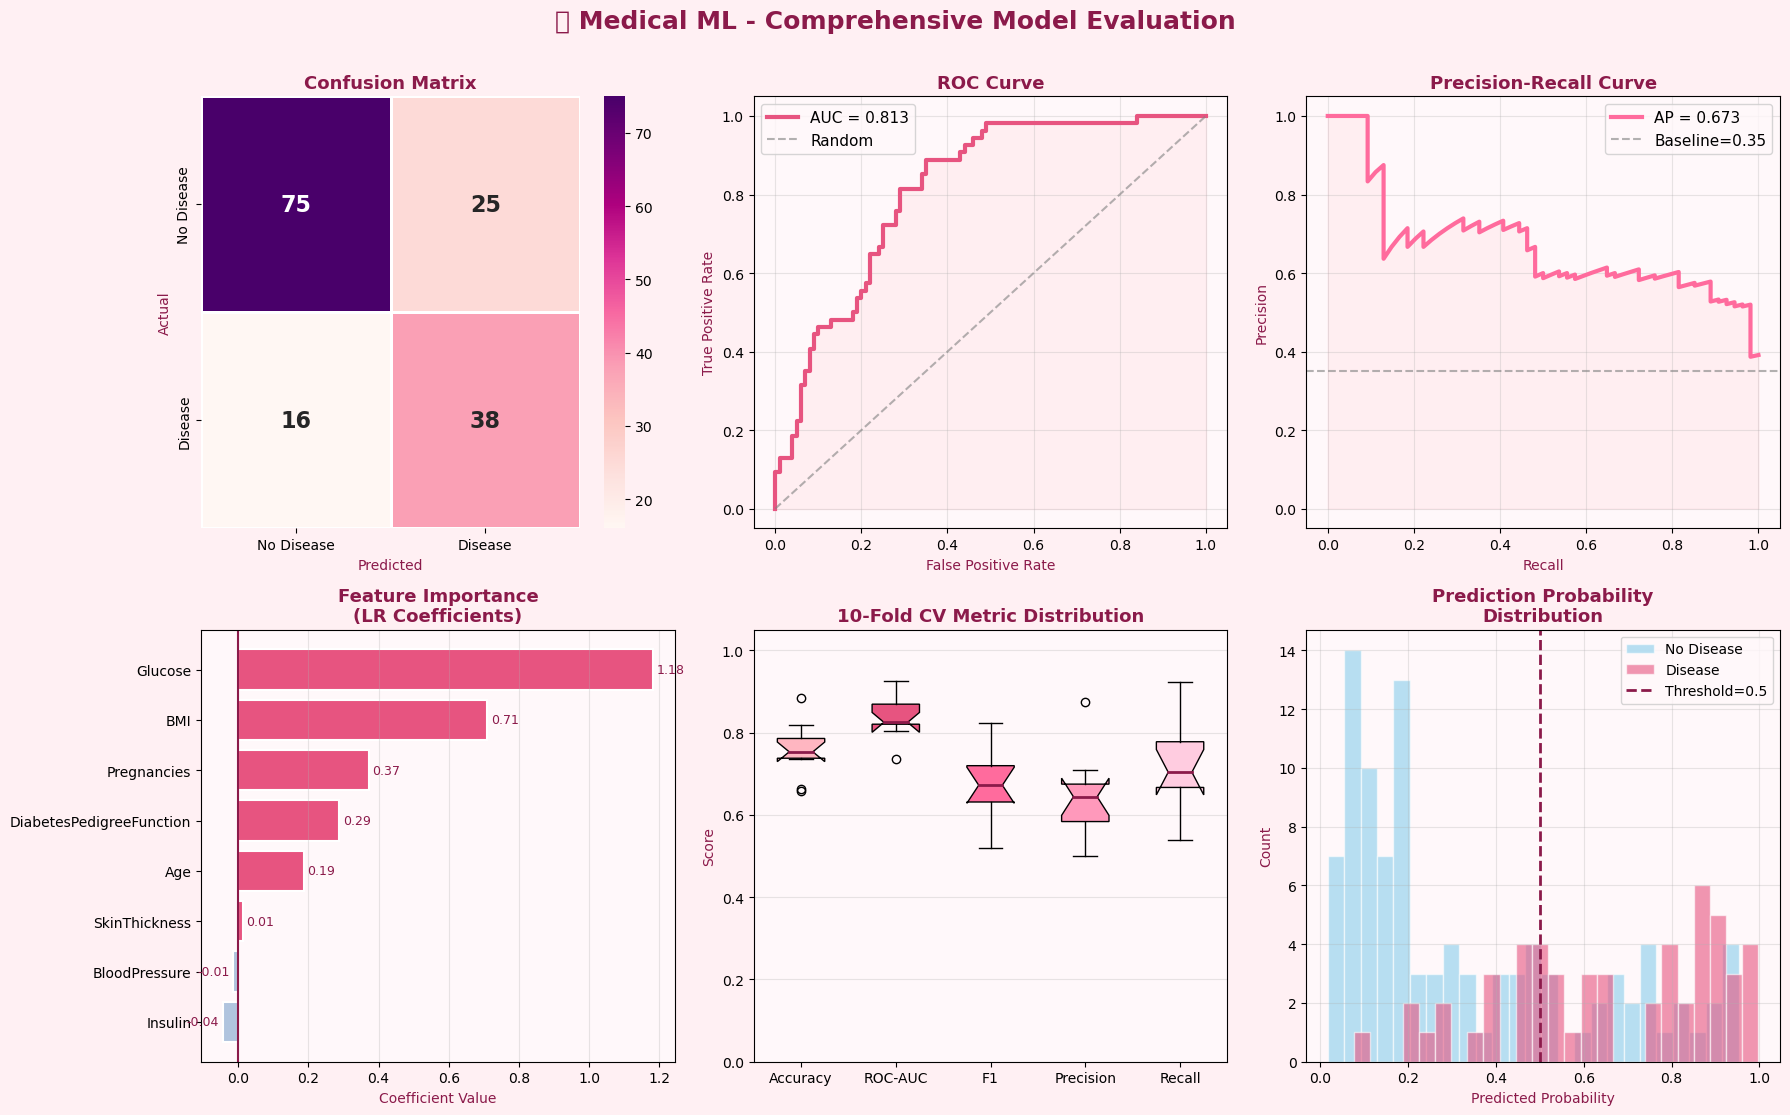

✅ Evaluation plots saved!


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.patch.set_facecolor('#fff0f3')
fig.suptitle('🏥 Medical ML - Comprehensive Model Evaluation', fontsize=18, fontweight='bold', color='#8b1a4a', y=1.01)

PINK = '#e75480'
LIGHT_PINK = '#ffb6c1'
DARK_PINK = '#8b1a4a'
ACCENT = '#ff6b9d'

# ── 1. Confusion Matrix ──
ax = axes[0, 0]
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu', ax=ax,
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'],
            linewidths=2, linecolor='white', annot_kws={'size': 16, 'weight': 'bold'})
ax.set_title('Confusion Matrix', fontweight='bold', color=DARK_PINK, fontsize=13)
ax.set_xlabel('Predicted', color=DARK_PINK)
ax.set_ylabel('Actual', color=DARK_PINK)

# ── 2. ROC Curve ──
ax = axes[0, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
ax.plot(fpr, tpr, color=PINK, lw=3, label=f'AUC = {auc:.3f}')
ax.fill_between(fpr, tpr, alpha=0.15, color=LIGHT_PINK)
ax.plot([0,1],[0,1],'--', color='gray', alpha=0.6, label='Random')
ax.set_xlabel('False Positive Rate', color=DARK_PINK)
ax.set_ylabel('True Positive Rate', color=DARK_PINK)
ax.set_title('ROC Curve', fontweight='bold', color=DARK_PINK, fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

# ── 3. Precision-Recall Curve ──
ax = axes[0, 2]
prec, rec, _ = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)
ax.plot(rec, prec, color=ACCENT, lw=3, label=f'AP = {ap:.3f}')
ax.fill_between(rec, prec, alpha=0.15, color=LIGHT_PINK)
ax.axhline(y_test.mean(), linestyle='--', color='gray', alpha=0.6, label=f'Baseline={y_test.mean():.2f}')
ax.set_xlabel('Recall', color=DARK_PINK)
ax.set_ylabel('Precision', color=DARK_PINK)
ax.set_title('Precision-Recall Curve', fontweight='bold', color=DARK_PINK, fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

# ── 4. Feature Importance (Coefficients) ──
ax = axes[1, 0]
coefs = pd.Series(model.coef_[0], index=feature_cols).sort_values()
colors = [PINK if c > 0 else '#b0c4de' for c in coefs]
bars = ax.barh(coefs.index, coefs.values, color=colors, edgecolor='white', linewidth=1.5)
ax.axvline(0, color=DARK_PINK, linestyle='-', lw=1.5)
ax.set_title('Feature Importance\n(LR Coefficients)', fontweight='bold', color=DARK_PINK, fontsize=13)
ax.set_xlabel('Coefficient Value', color=DARK_PINK)
ax.grid(axis='x', alpha=0.3)
for bar, val in zip(bars, coefs.values):
    ax.text(val + (0.01 if val >= 0 else -0.01), bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9, color=DARK_PINK)

# ── 5. Cross-Validation Scores ──
ax = axes[1, 1]
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
metrics_cv = {
    'Accuracy': cross_val_score(model, scaler.fit_transform(X), y, cv=cv, scoring='accuracy'),
    'ROC-AUC': cross_val_score(model, scaler.fit_transform(X), y, cv=cv, scoring='roc_auc'),
    'F1': cross_val_score(model, scaler.fit_transform(X), y, cv=cv, scoring='f1'),
    'Precision': cross_val_score(model, scaler.fit_transform(X), y, cv=cv, scoring='precision'),
    'Recall': cross_val_score(model, scaler.fit_transform(X), y, cv=cv, scoring='recall'),
}
bp = ax.boxplot([v for v in metrics_cv.values()], labels=metrics_cv.keys(),
                patch_artist=True, notch=True, medianprops={'color': DARK_PINK, 'lw': 2})
colors_bp = [LIGHT_PINK, PINK, ACCENT, '#ff99bb', '#ffcce0']
for patch, c in zip(bp['boxes'], colors_bp):
    patch.set_facecolor(c)
ax.set_title('10-Fold CV Metric Distribution', fontweight='bold', color=DARK_PINK, fontsize=13)
ax.set_ylabel('Score', color=DARK_PINK)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1.05)

# ── 6. Probability Distribution ──
ax = axes[1, 2]
ax.hist(y_prob[y_test == 0], bins=25, alpha=0.6, color='#87ceeb', label='No Disease', edgecolor='white')
ax.hist(y_prob[y_test == 1], bins=25, alpha=0.6, color=PINK, label='Disease', edgecolor='white')
ax.axvline(0.5, color=DARK_PINK, linestyle='--', lw=2, label='Threshold=0.5')
ax.set_xlabel('Predicted Probability', color=DARK_PINK)
ax.set_ylabel('Count', color=DARK_PINK)
ax.set_title('Prediction Probability\nDistribution', fontweight='bold', color=DARK_PINK, fontsize=13)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('evaluation_plot.png', dpi=150, bbox_inches='tight', facecolor='#fff0f3')
plt.show()
print('✅ Evaluation plots saved!')

## 5️⃣ Classification Report

In [9]:
print('='*55)
print('         FULL CLASSIFICATION REPORT')
print('='*55)
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))
print('='*55)
print(f'\n⚠️  Why Accuracy Alone is NOT Enough:')
print(f'   If model always predicts "No Disease":')
print(f'   Accuracy = {(y_test==0).mean():.1%} ← looks OK!')
print(f'   Recall   = 0.000 ← misses ALL sick patients!')
print(f'\n   In medical diagnosis, RECALL is critical.')
print(f'   False Negatives (missed disease) > False Positives')

         FULL CLASSIFICATION REPORT
              precision    recall  f1-score   support

  No Disease       0.82      0.75      0.79       100
     Disease       0.60      0.70      0.65        54

    accuracy                           0.73       154
   macro avg       0.71      0.73      0.72       154
weighted avg       0.75      0.73      0.74       154


⚠️  Why Accuracy Alone is NOT Enough:
   If model always predicts "No Disease":
   Accuracy = 64.9% ← looks OK!
   Recall   = 0.000 ← misses ALL sick patients!

   In medical diagnosis, RECALL is critical.
   False Negatives (missed disease) > False Positives


## 6️⃣ Save Model for Flask API

In [10]:
os.makedirs('../model', exist_ok=True)
joblib.dump(model, '../model/disease_model.pkl')
joblib.dump(scaler, '../model/scaler.pkl')

import json
model_info = {
    'features': feature_cols,
    'accuracy': float(accuracy_score(y_test, y_pred)),
    'roc_auc': float(roc_auc_score(y_test, y_prob)),
    'f1': float(f1_score(y_test, y_pred)),
    'precision': float(precision_score(y_test, y_pred)),
    'recall': float(recall_score(y_test, y_pred)),
    'coefficients': dict(zip(feature_cols, model.coef_[0].tolist()))
}
with open('../model/model_info.json', 'w') as f:
    json.dump(model_info, f, indent=2)

print('✅ Model saved to ../model/')
print('\nModel Performance Summary:')
for k, v in model_info.items():
    if k not in ['features', 'coefficients']:
        print(f'  {k:10s}: {v:.4f}')

✅ Model saved to ../model/

Model Performance Summary:
  accuracy  : 0.7338
  roc_auc   : 0.8126
  f1        : 0.6496
  precision : 0.6032
  recall    : 0.7037
